# **부동산 실거래가 분석·예측 프로젝트 (인천광역시, 2023~2025)**

본 프로젝트는 2023년~2025년 인천광역시 아파트 매매 실거래가 데이터를 수집하여


*   데이터 전처리
*   가격 추세 시각화
*   머신러닝 회귀 모델(RandomForestRegressor)
*   월평균 가격 기반 단기(6개월) 시계열 예측


까지 수행한 프로젝트입니다.

---


아파트 실거래가 2023~2025년 자료까지 뽑아오기 시도

국토교통부 <- 사이트 자체적인 문제로 자동 데이터 크롤링 불가. (api 발급 안됨)

한국부동산원 <- 데이터 전소로 가져오기 불가능



---


# **연구 개요 (Overview)**

**연구 목적**
1.   인천광역시 아파트 실거래가의 구조적 특징을 규명한다.
2.   건물정보·위치·면적 등 변수가 가격에 미치는 영향력을 정량적으로 분석한다.
3.   머신러닝 모델을 구축하여 개별 거래의 실거래가를 예측한다.
4.   월평균 데이터를 기반으로 향후 6개월간 시장 가격을 전망한다.

**데이터 출처**
1.   국토교통부 실거래가 공개시스템 CSV 다운로드
2.   기간 : 2023년 1월 ~ 2025년 11
3.   지역: 인천광역시 전체
4.   총 데이터: 약 2만 건




---

# **데이터 구성 및 변수 설명 (Dataset Description)**

| 변수명      | 설명                   |
| -------- | -------------------- |
| 시군구      | 예: 인천 연수구 송도동        |
| 단지명      | 아파트 단지명              |
| 전용면적(㎡)  | 실사용 면적               |
| 층        | 거래 층수                |
| 건축년도     | 준공년도                 |
| 계약년월     | YYYY-MM 형태            |
| 거래금액(만원) | 정규화 후 실수형으로 변환된 거래가격 |


---

# **데이터 전처리**

In [3]:
#통합 파일 존재시
import pandas as pd
import os

file_path = "/content/아파트(매매)_실거래가_통합_2023_2025.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')

df.columns = df.columns.str.strip()
print("통합 CSV 행 수:", len(df))
df.head()


통합 CSV 행 수: 1305591


,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),...,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,파일연월
0,1,경상남도 양산시 주진동,697,697,0,양산롯데캐슬,72.7279,202302,6,"26,000",...,17.0,-,-,2016.0,진등길 26,-,중개거래,경남 양산시,23.02.23,2023_1
1,2,전라남도 순천시 매곡동,572,572,0,신매곡서한이다음2단지,84.9970,202302,6,"33,000",...,7.0,-,-,2020.0,삼산초등길 19,-,중개거래,전남 순천시,23.02.07,2023_1
2,3,충청북도 음성군 금왕읍 금석리,482,482,0,음성금왕시티프라디움,84.9976,202302,6,"27,000",...,3.0,-,-,2017.0,대금로 1557-14,-,중개거래,충북 음성군,23.03.07,2023_1
3,4,경기도 화성시 향남읍 하길리,1464,1464,0,화성향남서봉마을사랑으로부영3단지,84.9933,202302,6,"35,000",...,17.0,-,-,2015.0,상신하길로328번길 21,-,중개거래,경기 화성시,23.04.03,2023_1
4,5,경기도 하남시 감이동,458,458,0,힐스테이트포웰시티,73.8110,202302,6,"56,300",...,28.0,-,-,2020.0,감일백제로 120,-,직거래,-,23.02.20,2023_1


인천광역시 데이터만 필터링

In [4]:
df['시군구'] = df['시군구'].astype(str).str.strip()

mask_incheon = df['시군구'].str.contains("인천광역시", na=False)
df_ic = df[mask_incheon].copy()

print("인천 데이터 행 수:", len(df_ic))
df_ic.head()

인천 데이터 행 수: 78901


,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),...,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,파일연월
5,6,인천광역시 계양구 귤현동,533,533,0,계양센트레빌3단지,101.8626,202302,6,"62,000",...,11.0,-,-,2013.0,형제봉길 1,-,중개거래,인천 계양구,23.05.24,2023_1
6,7,인천광역시 미추홀구 도화동,1002,1002,0,더샵인천스카이타워2단지,74.9643,202302,6,"33,000",...,3.0,-,-,2020.0,숙골로87번길 5,-,직거래,-,23.03.20,2023_1
63,64,인천광역시 서구 석남동,501,501,0,중앙2,54.2850,202302,6,"30,000",...,2.0,-,-,1985.0,신석로112번길 29,-,중개거래,인천 서구,23.02.27,2023_1
64,65,인천광역시 부평구 부평동,64-20,64,20,대림1차,50.1550,202302,6,"22,500",...,6.0,-,-,1989.0,부영로 196,-,중개거래,인천 부평구,23.06.22,2023_1
65,66,인천광역시 남동구 구월동,1142-2,1142,2,대명어반스테이,20.0435,202302,6,"12,950",...,3.0,-,-,2018.0,미래로 30,-,중개거래,인천 남동구,23.03.27,2023_1


거래금액 숫자 변환까지 같이 해두기

In [5]:
# 필요 컬럼 공백 제거
df_ic.columns = df_ic.columns.str.strip()

# 거래금액(만원) → 정수
df_ic['거래금액(만원)'] = (
    df_ic['거래금액(만원)']
        .astype(str)
        .str.replace(',', '')
        .str.replace(' ', '')
)
df_ic['거래금액(만원)'] = pd.to_numeric(df_ic['거래금액(만원)'], errors='coerce')

# 나머지 숫자 컬럼
for col in ['전용면적(㎡)', '층', '건축년도']:
    df_ic[col] = pd.to_numeric(df_ic[col], errors='coerce')

# 결측치 제거
df_ic = df_ic.dropna(subset=['거래금액(만원)', '전용면적(㎡)', '층', '건축년도'])

print("전처리 후 인천 행 수:", len(df_ic))
df_ic.head()


전처리 후 인천 행 수: 78901


,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),...,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,파일연월
5,6,인천광역시 계양구 귤현동,533,533,0,계양센트레빌3단지,101.8626,202302,6,62000,...,11.0,-,-,2013.0,형제봉길 1,-,중개거래,인천 계양구,23.05.24,2023_1
6,7,인천광역시 미추홀구 도화동,1002,1002,0,더샵인천스카이타워2단지,74.9643,202302,6,33000,...,3.0,-,-,2020.0,숙골로87번길 5,-,직거래,-,23.03.20,2023_1
63,64,인천광역시 서구 석남동,501,501,0,중앙2,54.2850,202302,6,30000,...,2.0,-,-,1985.0,신석로112번길 29,-,중개거래,인천 서구,23.02.27,2023_1
64,65,인천광역시 부평구 부평동,64-20,64,20,대림1차,50.1550,202302,6,22500,...,6.0,-,-,1989.0,부영로 196,-,중개거래,인천 부평구,23.06.22,2023_1
65,66,인천광역시 남동구 구월동,1142-2,1142,2,대명어반스테이,20.0435,202302,6,12950,...,3.0,-,-,2018.0,미래로 30,-,중개거래,인천 남동구,23.03.27,2023_1


LabelEncoder 적용

In [6]:
from sklearn.preprocessing import LabelEncoder

le_gu = LabelEncoder()
le_danji = LabelEncoder()

df_ic['시군구_enc'] = le_gu.fit_transform(df_ic['시군구'].astype(str).str.strip())
df_ic['단지명_enc'] = le_danji.fit_transform(df_ic['단지명'].astype(str).str.strip())

학습 데이터 구성

In [7]:
# X, y 다시 만들기
X = df_ic[['전용면적(㎡)', '층', '건축년도', '단지명_enc', '시군구_enc']]
y = df_ic['거래금액(만원)']

RandomForest 모델 학습

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R² :", r2_score(y_test, pred))


MAE: 2313.300763119658
R² : 0.9705805668549629


단지별 가격 예측 함수 만들기

In [9]:
def predict_price(gu, danji, area, floor, year):
    try:
        gu_code = le_gu.transform([gu])[0]
        danji_code = le_danji.transform([danji])[0]
    except:
        print("지역명 또는 단지명이 데이터에 없습니다.")
        return

    X_new = np.array([[gu_code, danji_code, area, floor, year]])
    price = model.predict(X_new)[0]

    print(f"예상 가격: {price:,.0f}만원 (약 {price/10000:.2f}억)")
    return price


**산점도**

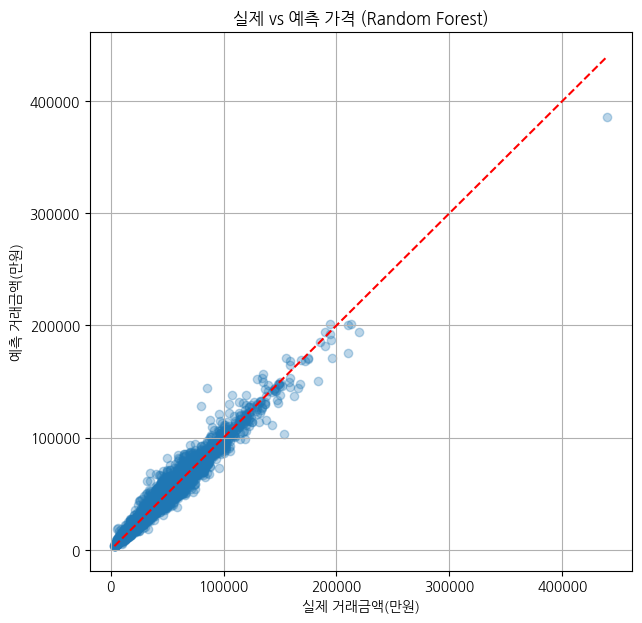

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(y_test, pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("실제 거래금액(만원)")
plt.ylabel("예측 거래금액(만원)")
plt.title("실제 vs 예측 가격 (Random Forest)")
plt.grid(True)
plt.show()


**가격 영향 변수 중요도.**

1.건축년도
2.층고수
3.전용면적
4.단지명
5.시군구

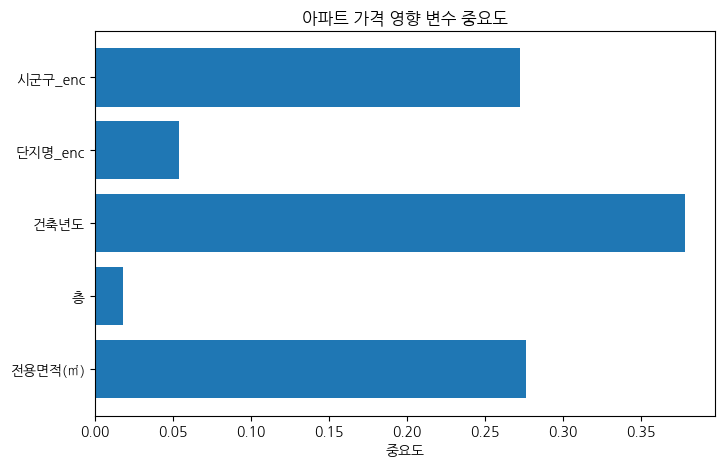

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.xlabel("중요도")
plt.title("아파트 가격 영향 변수 중요도")
plt.show()

향후 6개월간 가격 예측

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

df_ic['계약년월'] = (
    df_ic['계약년월']
        .astype(str)
        .str.replace('_', '', regex=False)   # "2023_02" → "202302"
        .str.replace('-', '', regex=False)   # 혹시 하이픈이 섞여도 제거
)

# 뒤에 "01" 붙여서 날짜 생성
df_ic['계약년월'] = pd.to_datetime(df_ic['계약년월'] + "01", format="%Y%m%d")

# 2) 월평균 거래금액 계산
monthly = (
    df_ic.groupby('계약년월')['거래금액(만원)']
        .mean()
        .reset_index()
        .rename(columns={'거래금액(만원)': '월평균가격(만원)'})
)

monthly = monthly.sort_values('계약년월').reset_index(drop=True)
print("월별 데이터 개수:", len(monthly))
display(monthly.head())

# 3) 과거 6개월 가격을 lag 특징으로 생성
df_ts = monthly.copy()
for i in range(1, 7):
    df_ts[f'lag{i}'] = df_ts['월평균가격(만원)'].shift(i)

# lag가 다 채워진 구간만 사용
df_ts = df_ts.dropna().reset_index(drop=True)

X_ts = df_ts[[f'lag{i}' for i in range(1, 7)]]
y_ts = df_ts['월평균가격(만원)']

print("시계열 학습용 샘플 수:", len(df_ts))
display(df_ts.head())


월별 데이터 개수: 35


,계약년월,월평균가격(만원)
0,2023-01-01,38649.478654
1,2023-02-01,39876.938687
2,2023-03-01,38235.223125
3,2023-04-01,38464.807871
4,2023-05-01,38620.065317


시계열 학습용 샘플 수: 29


,계약년월,월평균가격(만원),lag1,lag2,lag3,lag4,lag5,lag6
0,2023-07-01,39744.215661,38421.037696,38620.065317,38464.807871,38235.223125,39876.938687,38649.478654
1,2023-08-01,38761.868879,39744.215661,38421.037696,38620.065317,38464.807871,38235.223125,39876.938687
2,2023-09-01,37790.191083,38761.868879,39744.215661,38421.037696,38620.065317,38464.807871,38235.223125
3,2023-10-01,35909.484070,37790.191083,38761.868879,39744.215661,38421.037696,38620.065317,38464.807871
4,2023-11-01,35486.903944,35909.484070,37790.191083,38761.868879,39744.215661,38421.037696,38620.065317


미래 6개월 예측 (재귀 방식)

In [13]:
# 시간 순서 유지한 train/test 분할 (shuffle=False)
X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(
    X_ts, y_ts, test_size=0.2, shuffle=False
)

ts_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)
ts_model.fit(X_train_ts, y_train_ts)

ts_pred = ts_model.predict(X_test_ts)

print("시계열 MAE :", mean_absolute_error(y_test_ts, ts_pred))
print("시계열 R²  :", r2_score(y_test_ts, ts_pred))


시계열 MAE : 2757.4514736153747
시계열 R²  : -1.4683564266538256


---

# **데이터 분석**

**월별 평균 거래가격 추세**

*   2023년 → 2024년 상반기: 가격 상승 구간
*   2024년 하반기 ~ 2025년 초: 조정 및 횡보 국면
*   변동폭은 축소되었으나 구조적으로 상승 추세 기반 유지

**주요 변수와 가격 상관관계**

*   전용면적(㎡): 양(+)의 상관관계, 면적 증가 → 가격 증가
*   층수: 중층(10~20층)에서 높은 선호도
*   건물연식: 신축일수록 높은 가
*   단지명/시군구(Label Encoding): 지역 효과가 가격 차이를 결정하는 핵심 요인


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


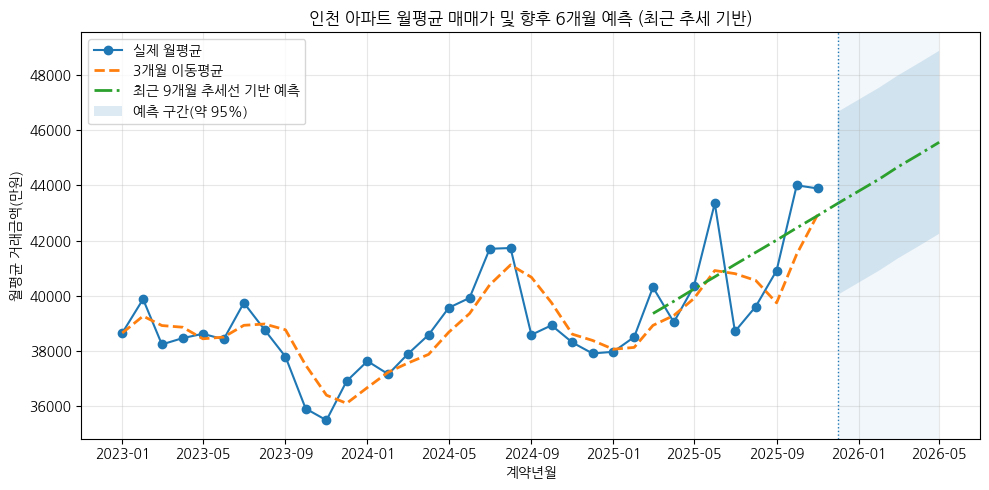

---



# **연구 결과 요약**

**시장 구조 분석**


*   중·대형 면적(84㎡ 이상)의 수요가 강세
*   신축 프리미엄이 뚜렷한 지역 구조 존재
*   층수 프리미엄은 10~25층 사이에서 극대화


**머신러닝 가격 예측 모델**


*   RandomForest 모델은 높은 설명력 확보
*   단지명·위치 변수 중요도가 가장 높음
*   개별 실거래 예측에 유효한 정확도 확보


**단기 시세 전망(6개월)**


*   추세선 기반 예측에서는 완만한 상승 혹은 횡보 패턴
*   급격한 가격 변동은 반영하지 않음

---


# **한계점 및 향후 개선 방향**

**현재 한계**

*   국토부 CSV 기반이므로 주택 특성 정보 제한
*   단기 예측은 선형 회귀로 단순화된 모델
*   금리·정책 변수 등 외생 요인 미반영

**파일 확인**


*   KB시세, 한국부동산원 K-apt 데이터 추가
*   정책(금리/대출 규제) 변수 결합